<h1> Experiment anti HOM probability against bandwith </h1>

In [27]:
#General imports
resol = 300
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})

import sys
import numpy as np
from pathlib import Path
pi = np.pi

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

#Local imports
from experiments.coincidence_vs_bandwith import run_coincidence_vs_bandwith

<h2> Execute the experiment </h2>

Given an off-resonant scattering experiment, we test three different reference frequencies, and different IR cutoff

In [ ]:
omega_A = 10*pi
Gamma = 5*pi

#Prepare the photon frequencies
omega_q_tab = [9*pi, 8*pi, 7*pi, 6*pi, 5*pi]

sym_variables = False
n_bare = 2
#Run the experiments depending on the d.o.f of interest

if sym_variables:
        
    omega_ref_values = [12*pi, 11*pi, 10*pi, 9*pi, 8*pi]
    nb_pts_bandwith = 30

    for q in range(len(omega_q_tab)):

        index_omega_q = q + 1
        omega_q = omega_q_tab[q]

        for i in range(len(omega_ref_values)):
            index_experiment = i+1
            print("Running frequency window ", index_experiment, " out of ", len(omega_ref_values))
                
            lbda_tab = np.linspace(pi, omega_ref_values[i], nb_pts_bandwith)
            ir_tab = omega_ref_values[i] - lbda_tab
            uv_tab = omega_ref_values[i] + lbda_tab

            _, _, coincidence_tab = run_coincidence_vs_bandwith(omega_q, ir_tab, uv_tab, index_omega_q, index_experiment, n=n_bare,
                                                                    sym_variables=sym_variables, store_results=True, progress=True)
            
        print("------------- \n")

else:

    ir_values = [0, pi, 2*pi, 3*pi, 4*pi]
    nb_pts_bandwith = 30

    for q in range(len(omega_q_tab)):

        index_omega_q = q + 1
        omega_q = omega_q_tab[q]

        for i in range(len(ir_values)):
            index_experiment = i+1
            print("Running frequency window ", index_experiment, " out of ", len(ir_values))

            ir_tab = ir_values[i] * np.ones(nb_pts_bandwith)
            uv_tab = np.linspace(1.1*ir_values[i], 30*pi, nb_pts_bandwith)

            _, _, coincidence_tab = run_coincidence_vs_bandwith(omega_q, ir_tab, uv_tab, index_omega_q, index_experiment, n=n_bare,
                                                                    sym_variables=sym_variables, store_results=True, progress=True)
        
        print("------------- \n")

<h2> Convergence per frequency window </h2>

Recover the data

In [25]:
omega_A = 10*pi
Gamma = 5*pi
delta_q = 0.05*pi

sym_variables = False
omega_q_tab = [9*pi, 8*pi, 7*pi, 6*pi, 5*pi]


index_experiment = 1

coincidence_to_plot = []
theoretical_values = []
relative_errors = []
lbda_tab_to_plot = []

#for i in range(len(omega_q_tab)):
for i in [0,1,2]:
    index_omega_q = i+1
    omega_q = omega_q_tab[i]

    #Recover the data

    if sym_variables:
        data_file = f"../results/csv_files/sym_variables/coincidence_vs_bandwith_{index_omega_q}_{index_experiment}.csv"
    else:
        data_file = f"../results/csv_files/iruv_variables/coincidence_vs_bandwith_{index_omega_q}_{index_experiment}.csv"

    df = pd.read_csv(data_file)
    coincidence_to_plot.append(df['coincidence_tab'].to_numpy())
    ir_tab = df['ir_tab'].to_numpy()
    uv_tab = df['uv_tab'].to_numpy()
    lbda_tab_to_plot.append(0.5*(uv_tab - ir_tab))

    #Comparision with theoretical value for each scattering experiment
    R_theory_physical = 1 / (1 + ((omega_q_tab[index_omega_q-1] - omega_A)/ (Gamma/2))**2)
    theoretical_val = 1 - 4*R_theory_physical*(1-R_theory_physical)

    if np.abs(theoretical_val) < 1e-1:
        non_monochr_ratio = Gamma / (2*delta_q)
        theoretical_val += 1/(np.sqrt(pi) * non_monochr_ratio)
    
    theoretical_values.append(theoretical_val)

    #relative error
    relative_errors.append(np.abs(coincidence_to_plot[-1][-1] - theoretical_val) / theoretical_val)

Create the figure

Relative error for omega_q = 9.0 pi: 8.125 %
Relative error for omega_q = 8.0 pi: 20.447 %
Relative error for omega_q = 7.0 pi: 18.537 %


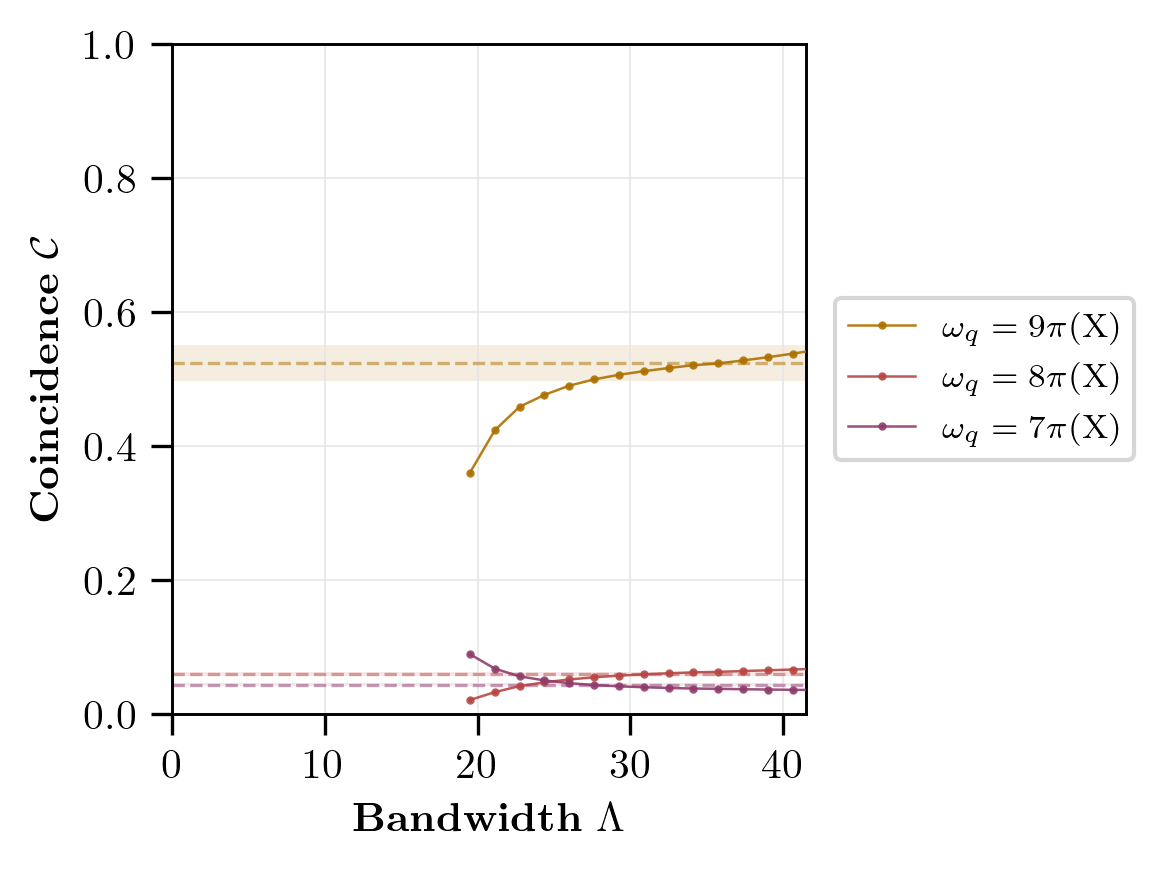

In [26]:
# Figure setup (même ADN que ta figure de référence)
fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

# Palette sobre + markers distincts
colors  = ["#ad7100", "#b74744", "#903d6e", "#4b4477", "#003f5c"]
labels  = [r'$\omega_q = 9\pi$', r'$\omega_q = 8\pi$', r'$\omega_q = 7\pi$', r'$\omega_q = 6\pi$', r'$\omega_q = 5\pi$']
lbda_conv = np.zeros(len(omega_q_tab))

# Scatter plots
#for i in range(len(omega_q_tab)):
for i in [0,1,2]:
    print(f"Relative error for omega_q = {omega_q_tab[i]/pi:.1f} pi: {relative_errors[i]*100:.3f} %")
    #Index where the curve enters the 5% confidence region
    if (coincidence_to_plot[i][-1] > 0.95*theoretical_values[i] and coincidence_to_plot[i][-1] < 1.05 * theoretical_values[i]):
        lbda_conv[i] = lbda_tab_to_plot[i][np.where((coincidence_to_plot[i] < 1.05*theoretical_values[i]) & 
                                                    (coincidence_to_plot[i] > 0.95*theoretical_values[i]))[0][0]]
        labels[i] += '(O)'
    else:
        lbda_conv[i] = np.inf
        labels[i] += '(X)'

    ax.plot(
        lbda_tab_to_plot[i],
        coincidence_to_plot[i],
        marker="o",
        color=colors[i],
        label = labels[i],
        markersize=1,
        linewidth=0.6,
        alpha=0.9,
        zorder=3
    )
    #5% confidence region
    ax.hlines(theoretical_values[i], 0, 1.1*12*pi,color=colors[i], alpha=0.5, linewidth=0.8, linestyle='--')
    ax.fill_between(np.linspace(0, 1.1*12*pi, 100),
                    0.95*theoretical_values[i],
                    1.05*theoretical_values[i],color=colors[i],alpha=0.12,linewidth=0, zorder=1)

#Indicate largest lbda_conv if non nan (ie all curves enter the confidence region)
max_lbda_conv = np.max(lbda_conv)
if not np.isinf(max_lbda_conv):
    #Display numerical lbda_conv in pi units
    ax.text(
        0.92 * max_lbda_conv/(10*pi),
        0.85,
        r'$\Lambda_{\mathrm{conv}} \approx ' + f"{max_lbda_conv/pi:.1f}" + r'\pi$',
        color='black',
        fontsize=9,
        va='center',
        ha='left',
        transform=ax.get_yaxis_transform()
    )
    ax.vlines(max_lbda_conv, 0, 1, color='black', alpha=0.5, linestyle='--', linewidth=0.8)

#legend outside the plot
ax.legend(
    prop={'size': 8},
    frameon=True,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)

# Axes scaling and limits
ax.set_xlim(0, 1.1*12*pi)
ax.set_ylim([0,1])

#ax.set_xticks([2*pi, 4*pi, 6*pi, 8*pi, 10*pi, 12*pi])
#ax.set_xticklabels([r"$2\pi$", r"$4\pi$", r"$6\pi$", r"$8\pi$", r"$10\pi$", r"$12\pi$"])

# Labels
ax.set_xlabel(r'\textbf{Bandwidth} $\Lambda$', fontsize=13)
ax.set_ylabel(r'\textbf{Coincidence} $\mathcal{C}$', fontsize=13)

#grid
ax.grid(color='0.9', linestyle='-', linewidth=0.4)

# Legend (sobre, sans cadre)
#ax.legend(prop={'size': 8}, frameon=False, loc="best")

# Tick appearance
ax.tick_params(axis='both', which='major', length=5, width=0.8)
ax.tick_params(axis='both', which='minor', length=3, width=0.6)

#font size
for item in [ax.xaxis.label, ax.yaxis.label]:
    item.set_fontsize(10)

for item in (ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(10)

plt.tight_layout()
#plt.savefig("../results/fig/coincidence_vs_bandwith_experiment_irfixed_"+str(index_experiment)+".pdf", bbox_inches="tight")
plt.show()

In [ ]:
#Test : print relative errors against omega_ref for each omega_q

omega_A = 10*pi
Gamma = 5*pi
delta_q = 0.05*pi

omega_q_tab = [9*pi, 8*pi, 7*pi, 6*pi, 5*pi]
omega_ref_values = [12*pi, 11*pi, 10*pi, 9*pi, 8*pi]


relative_errors = np.zeros((5,5))

for i in range(len(omega_q_tab)):
    for j in range(len(omega_ref_values)):
        #Recover the data
        data_file = f"../results/csv_files/antiHOM_vs_bandwith_{i+1}_{j+1}.csv"
        df = pd.read_csv(data_file)
        coincidence_to_plot = df['antiHOM_proba_tab'].to_numpy()
        lbda_tab_to_plot = df['lbda_tab'].to_numpy()

        #Comparision with theoretical value for each scattering experiment
        R_theory_physical = 1 / (1 + ((omega_q_tab[i] - omega_A)/ (Gamma/2))**2)
        theoretical_val = 1 - 4*R_theory_physical*(1-R_theory_physical)

        if np.abs(theoretical_val) < 1e-1:
            non_monochr_ratio = Gamma / (2*delta_q)
            theoretical_val += 1/(np.sqrt(pi) * non_monochr_ratio)
        
        relative_errors[i,j] = np.abs(coincidence_to_plot[-1] - theoretical_val) / theoretical_val